# Heart Disease Prediction

Simple project to predict whether a person has heart disease using the UCI heart dataset.
Steps: load data -> explore data (EDA) -> clean data -> train models -> check accuracy.

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
%matplotlib inline

## 2. Load the dataset

In [2]:
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 3. Explore the data (EDA)

In [3]:
df.shape

(303, 14)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(1)

No missing values, so we don't need to fill anything. Just dropping the duplicate row.

In [8]:
df = df.drop_duplicates()
df.shape

(302, 14)

### Target balance

In [9]:
df["target"].value_counts()

target
1    164
0    138
Name: count, dtype: int64

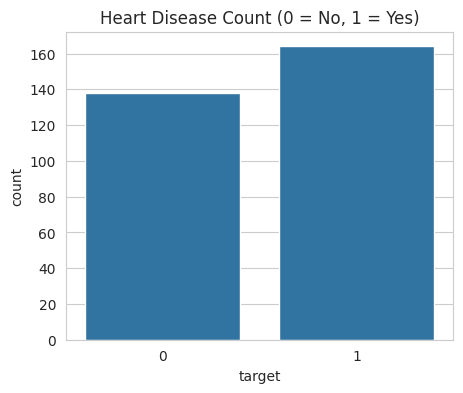

In [10]:
plt.figure(figsize=(5,4))
sns.countplot(x="target", data=df)
plt.title("Heart Disease Count (0 = No, 1 = Yes)")
plt.show()

### Age distribution

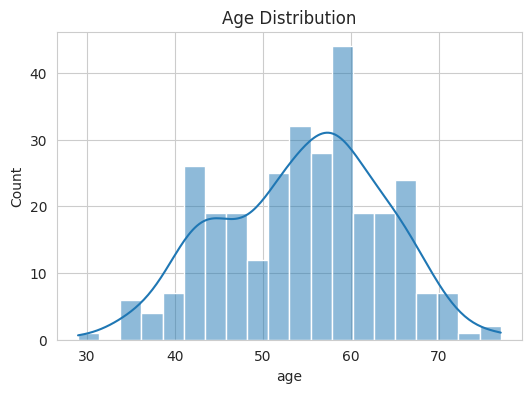

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(df["age"], kde=True, bins=20)
plt.title("Age Distribution")
plt.show()

### Disease by sex

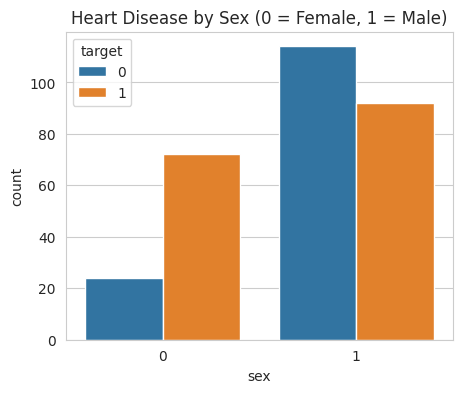

In [12]:
plt.figure(figsize=(5,4))
sns.countplot(x="sex", hue="target", data=df)
plt.title("Heart Disease by Sex (0 = Female, 1 = Male)")
plt.show()

### Chest pain type vs target

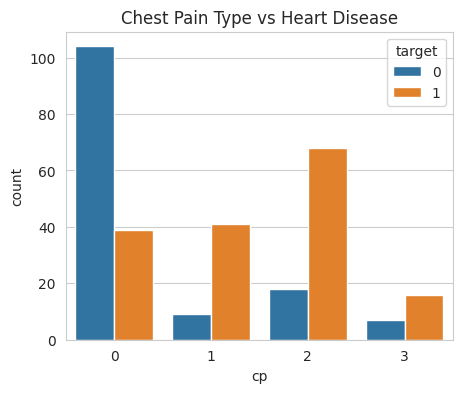

In [13]:
plt.figure(figsize=(5,4))
sns.countplot(x="cp", hue="target", data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

### Correlation heatmap

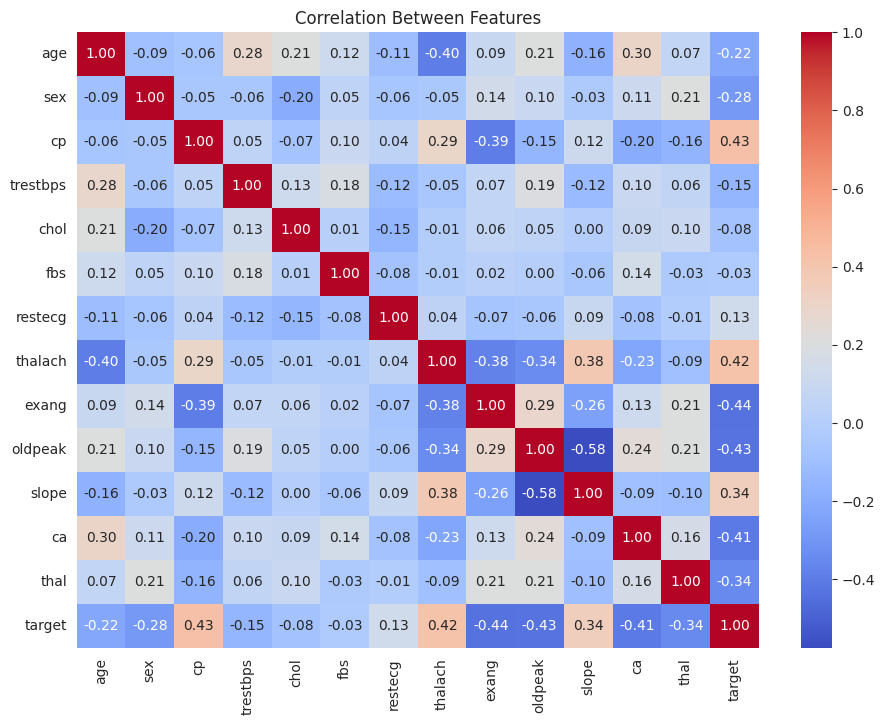

In [14]:
plt.figure(figsize=(11,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Features")
plt.show()

### Cholesterol vs age, colored by target

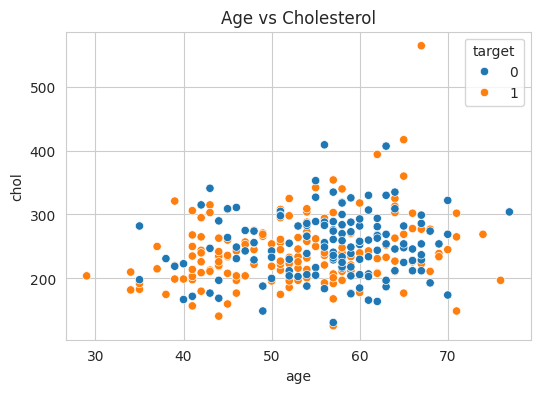

In [15]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="age", y="chol", hue="target", data=df)
plt.title("Age vs Cholesterol")
plt.show()

## 4. Prepare data for modeling

In [16]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((241, 13), (61, 13))

Scaling helps models like Logistic Regression and KNN work better.

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Train models

### Logistic Regression

In [18]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

log_preds = log_model.predict(X_test_scaled)
log_acc = accuracy_score(y_test, log_preds)
print("Logistic Regression Accuracy:", log_acc)

Logistic Regression Accuracy: 0.7868852459016393


### KNN

In [19]:
knn_model = KNeighborsClassifier(n_neighbors=9)
knn_model.fit(X_train_scaled, y_train)

knn_preds = knn_model.predict(X_test_scaled)
knn_acc = accuracy_score(y_test, knn_preds)
print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.8032786885245902


### Random Forest

In [20]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.8032786885245902


## 6. Compare models

In [21]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Random Forest"],
    "Accuracy": [log_acc, knn_acc, rf_acc]
})
results

,Model,Accuracy
0,Logistic Regression,0.786885
1,KNN,0.803279
2,Random Forest,0.803279


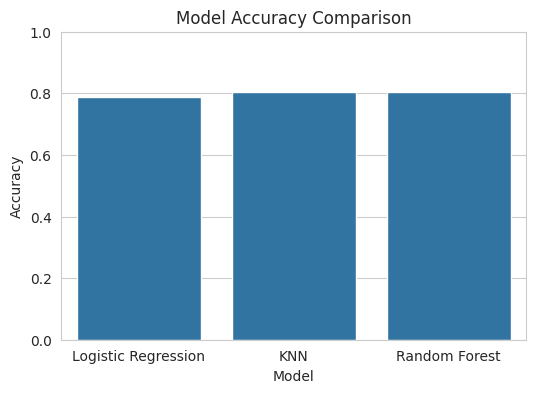

In [22]:
plt.figure(figsize=(6,4))
sns.barplot(x="Model", y="Accuracy", data=results)
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.show()

## 7. Closer look at the best model

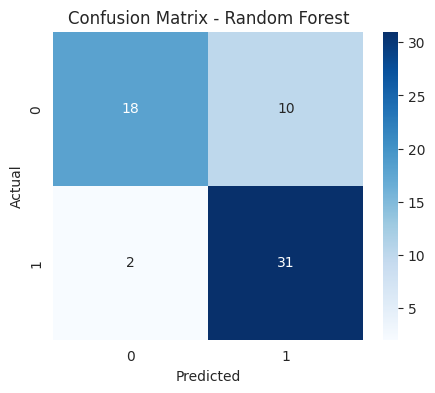

In [23]:
best_preds = rf_preds

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [24]:
print(classification_report(y_test, best_preds))

              precision    recall  f1-score   support

           0       0.90      0.64      0.75        28
           1       0.76      0.94      0.84        33

    accuracy                           0.80        61
   macro avg       0.83      0.79      0.79        61
weighted avg       0.82      0.80      0.80        61



### Which features matter most

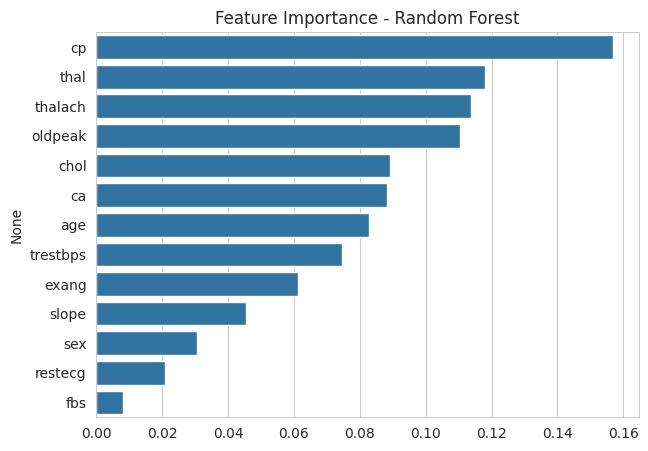

In [25]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7,5))
sns.barplot(x=importance.values, y=importance.index)
plt.title("Feature Importance - Random Forest")
plt.show()

## 8. Conclusion

- Dataset had no missing values, only 1 duplicate row removed.
- `cp`, `thalach`, `oldpeak`, `ca` and `thal` turned out to be the strongest features.
- Random Forest gave the best accuracy out of the 3 models tried.
- Accuracy is good for a small dataset like this (303 patients), could improve more with a bigger dataset or hyperparameter tuning.